# ESTADÍSTICA

* Verificar computacionalmente la validez de el Teorema Límite Central y el Teorema de Glivenko-
Cantelli.

* Familiarizarse con la simulación de las siguientes distribuciones: Uniforme, Exponencial,Pareto.


### **Teorema (Teorema del Límite Central):**

Sea $ X_1, X_2$ una sucesión infinita de variables aleatorias independientes e idénticamente distribuidas con media $\mu$ y varianza finita $sigma^2$. Entonces la función de distribución de la variable aleatoria

$$
Z = \frac{(X_1 + \dots + X_n) - n\mu}{\sqrt{n\sigma^2}}
$$

tiende a la función de distribución normal estándar cuando \( n \) tiende a infinito.

**Parte 1:** Simular variables aleatorias con distribución Exponencial y Pareto usando únicamente la función `np.random.uniform()` de numpy.


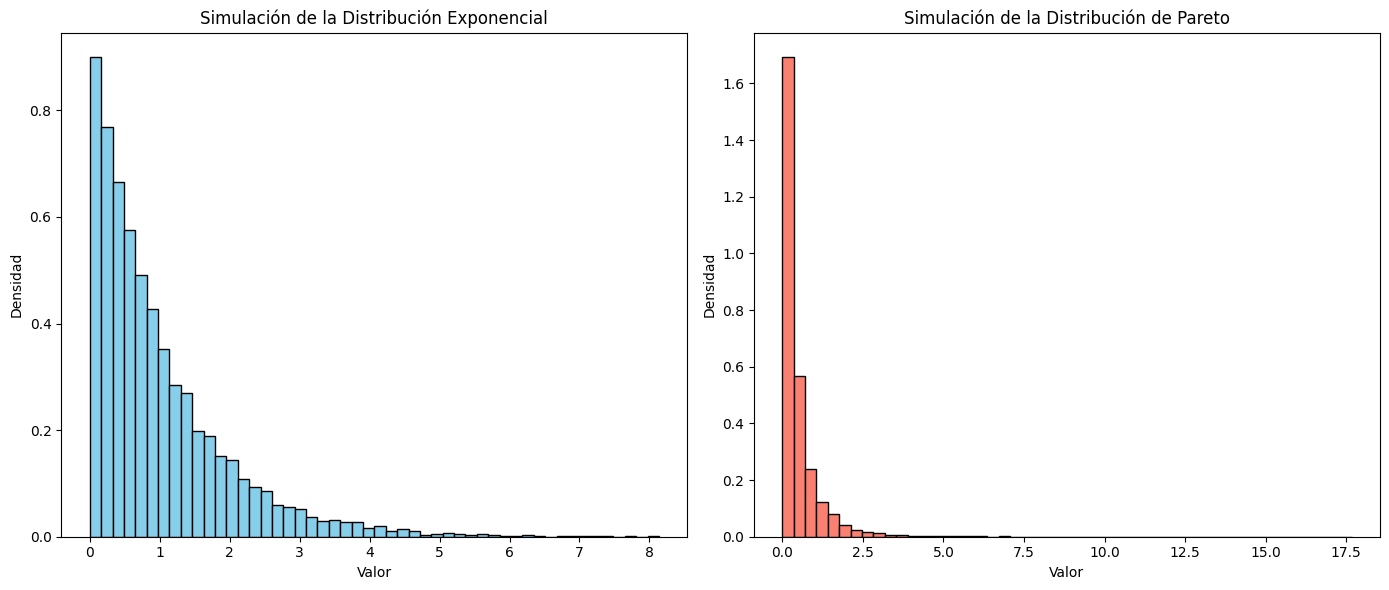

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Definimos los parámetros de las distribuciones
lambda_exp = 1  # Parámetro lambda para la distribución Exponencial
alpha_pareto = 3  # Parámetro alpha para la distribución de Pareto

# Simulación de la distribución Exponencial
# Usando la transformación inversa: X = -1/lambda * ln(1 - U)
n = 10000  # Número de muestras
uniform_samples_exp = np.random.uniform(0, 1, n)
exp_samples = -np.log(1 - uniform_samples_exp) / lambda_exp

# Simulación de la distribución de Pareto
# Usamos la transformación inversa: X = (1 - U)^(-1/alpha) - 1
uniform_samples_pareto = np.random.uniform(0, 1, n)
pareto_samples = (1 - uniform_samples_pareto) ** (-1 / alpha_pareto) - 1

# Visualizamos nuestros resultados
plt.figure(figsize=(14, 6))

# Histograma de la distribución Exponencial
plt.subplot(1, 2, 1)
plt.hist(exp_samples, bins=50, density=True, color='skyblue', edgecolor='black')
plt.title('Simulación de la Distribución Exponencial')
plt.xlabel('Valor')
plt.ylabel('Densidad')

# Histograma de la distribución de Pareto
plt.subplot(1, 2, 2)
plt.hist(pareto_samples, bins=50, density=True, color='salmon', edgecolor='black')
plt.title('Simulación de la Distribución de Pareto')
plt.xlabel('Valor')
plt.ylabel('Densidad')

plt.tight_layout()
plt.show()


**Parte 2:** Ahora deberán crear una función que calcule la variable aleatoria $Z$ del teorema del límite central.

Su función deberá recibir como parámetros:
- una lista con una muestra de variables aleatorias idénticamente distribuidas,
- un real que represente $ \mu $ (media),
- y un real que represente $ \sigma^2 $ (varianza).

La función deberá regresar el valor de $ Z $.


In [2]:
import numpy as np

def calcular_Z(muestra, mu, sigma2):
    """
    Calcula la variable aleatoria Z según el Teorema del Límite Central.

    Parámetros:
    - muestra: lista o array con una muestra de variables aleatorias i.i.d.
    - mu: valor de la media (μ) de la distribución de las variables aleatorias.
    - sigma2: valor de la varianza (σ^2) de la distribución de las variables aleatorias.

    Retorna:
    - El valor de la variable aleatoria Z.
    """
    n = len(muestra)
    suma_muestra = np.sum(muestra)
    Z = (suma_muestra - n * mu) / np.sqrt(n * sigma2)
    return Z

# Ejemplo de uso
# Generamos una muestra de variables aleatorias exponenciales con media 1 (mu = 1) y varianza 1 (sigma^2 = 1)
lambda_exp = 1
n = 1000
muestra_exponencial = -np.log(1 - np.random.uniform(0, 1, n)) / lambda_exp

# Calculamos Z usando la media y varianza conocidas para la distribución exponencial
mu = 1  # Media de la distribución exponencial con lambda = 1
sigma2 = 1  # Varianza de la distribución exponencial con lambda = 1

Z = calcular_Z(muestra_exponencial, mu, sigma2)
print("El valor de Z es:", Z)


El valor de Z es: -0.2849575752467286


**Parte 3:** Ya tenemos todo lo necesario para poner a prueba el Teorema del Límite Central. En esta parte deberán hacer lo siguiente para las distribuciones:
- Uniforme(0,1)
- Exponencial $( \lambda = 2 $)
- Pareto$( \alpha = 1, c = 1 $)
- Pareto$( \alpha = 2, c = 1 $)
- Pareto$( \alpha = 3, c = 2 $)

(a) Generar 1,000 variables aleatorias $ Z_n = \frac{\sum_{i=1}^{n} X_i - n\mu}{\sqrt{n\sigma^2}} $, usando $ n = 1,000 $ variables aleatorias $ X_1, X_2, \dots, X_n $ para cada una (son variables aleatorias i.i.d.).

(b) Graficar el histograma de las variables aleatorias $ Z_n $.

(c) Graficar sobre el histograma la función de densidad de la normal estándar:

$
f_{\text{normal}}(x; \mu, \sigma^2) = \frac{1}{\sqrt{2 \pi \sigma^2}} e^{-\frac{(x - \mu)^2}{2\sigma^2}}, \quad x \in (-\infty, \infty)
$


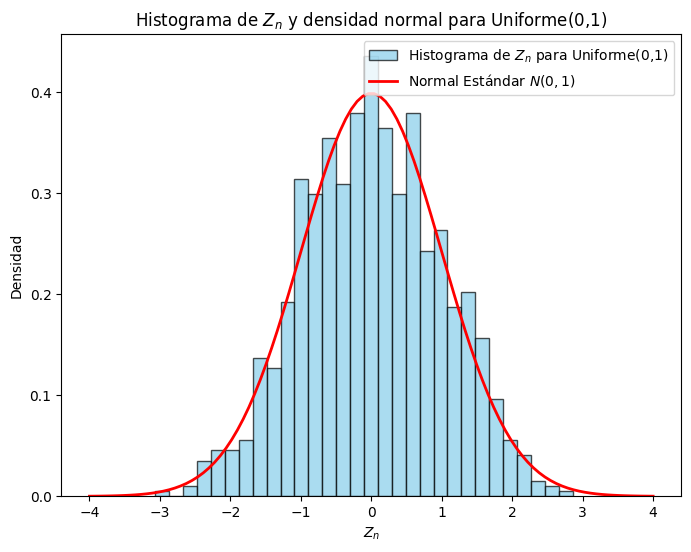

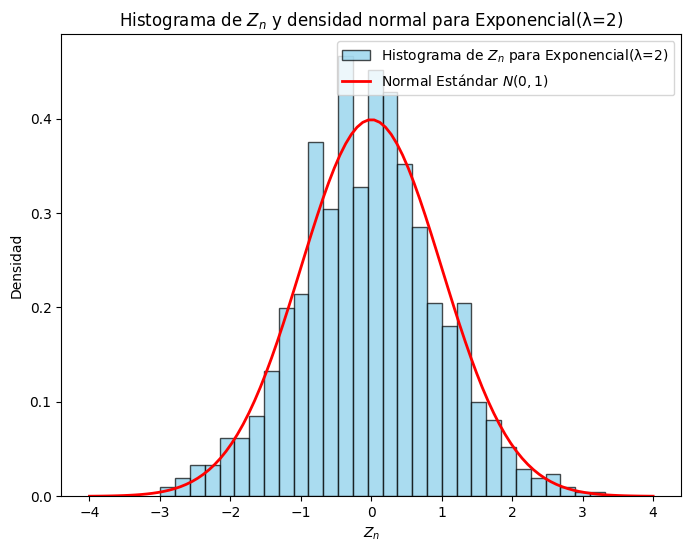

/usr/local/lib/python3.10/dist-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


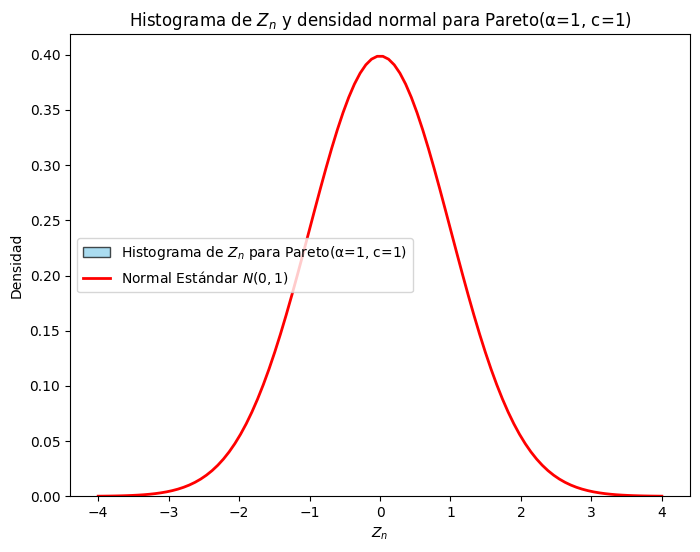

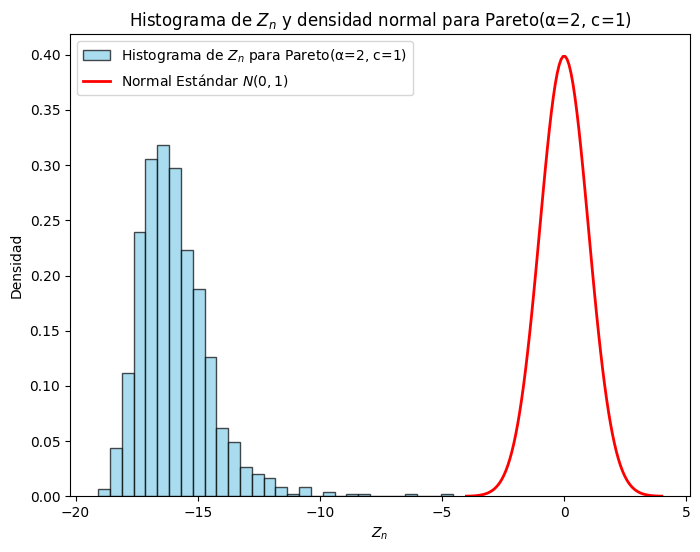

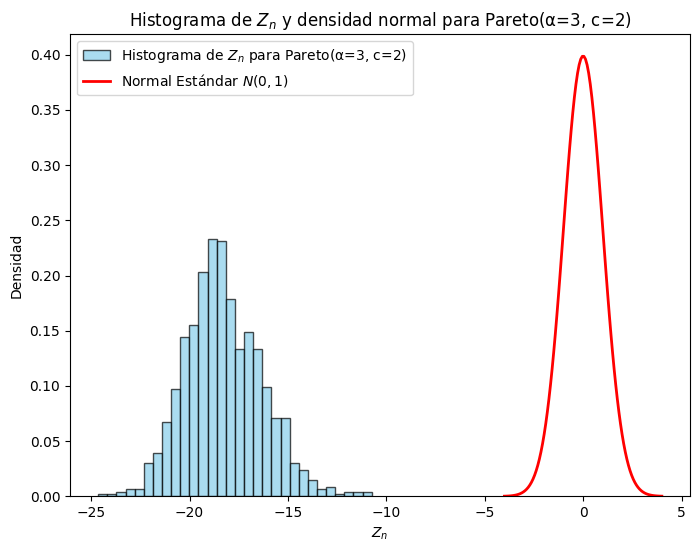

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Definimos la función para calcular Z según el Teorema del Límite Central
def calcular_Z(muestra, mu, sigma2):
    n = len(muestra)
    suma_muestra = np.sum(muestra)
    Z = (suma_muestra - n * mu) / np.sqrt(n * sigma2)
    return Z

# Parámetros de cada distribución
distribuciones = {
    "Uniforme(0,1)": {"mu": 0.5, "sigma2": 1/12, "sample_func": lambda n: np.random.uniform(0, 1, n)},
    "Exponencial(λ=2)": {"mu": 1/2, "sigma2": 1/4, "sample_func": lambda n: -np.log(1 - np.random.uniform(0, 1, n)) / 2},
    "Pareto(α=1, c=1)": {"mu": np.inf, "sigma2": np.inf, "sample_func": lambda n: (1 - np.random.uniform(0, 1, n)) ** (-1 / 1) - 1},
    "Pareto(α=2, c=1)": {"mu": 2, "sigma2": 4, "sample_func": lambda n: (1 - np.random.uniform(0, 1, n)) ** (-1 / 2) - 1},
    "Pareto(α=3, c=2)": {"mu": 1.5, "sigma2": 0.75, "sample_func": lambda n: (1 - np.random.uniform(0, 1, n)) ** (-1 / 3) * 2 - 2}
}

n = 1000  # Tamaño de la muestra para calcular cada Z_n
m = 1000  # Número de variables aleatorias Z_n a generar

for nombre, params in distribuciones.items():
    mu = params["mu"]
    sigma2 = params["sigma2"]
    generar_muestra = params["sample_func"]

    # Generamos las variables aleatorias Z_n
    Zn = []
    for _ in range(m):
        muestra = generar_muestra(n)
        if np.isfinite(mu) and np.isfinite(sigma2):  # Evitar distribuciones con media/varianza infinita
            Zn.append(calcular_Z(muestra, mu, sigma2))

    # Graficamos el histograma
    plt.figure(figsize=(8, 6))
    plt.hist(Zn, bins=30, density=True, color='skyblue', edgecolor='black', alpha=0.7, label=f'Histograma de $Z_n$ para {nombre}')

    # Superponemos la función de densidad de la normal estándar
    x = np.linspace(-4, 4, 100)
    plt.plot(x, norm.pdf(x, 0, 1), color='red', lw=2, label='Normal Estándar $N(0, 1)$')

    # Graficamos
    plt.title(f'Histograma de $Z_n$ y densidad normal para {nombre}')
    plt.xlabel('$Z_n$')
    plt.ylabel('Densidad')
    plt.legend()
    plt.show()


### **Definición (Función de Distribución Empírica):**
Sea $ X_1, \dots, X_n $ una muestra aleatoria de una población con función de distribución (f.d.) $ F $. Dada la muestra, definimos la función de distribución empírica (f.d.e.) $ \hat{F}_n $ por:

$
\hat{F}_n(x) = \frac{1}{n} \sum_{i=1}^{n} 1_{(-\infty, x]}(X_i) = \frac{1}{n} \# \{ i : X_i \leq x \}
$

Ahora recordemos qué nos dice el Teorema de Glivenko-Cantelli.

#### **Teorema (Glivenko-Cantelli):**
Sea $ X_1, \dots, X_n $ una colección de variables aleatorias independientes con distribución común $ F $ y sea $ \hat{F}_n(x) = \hat{F}_n(x, \omega) $ la función de distribución empírica correspondiente. Entonces:

$
\sup_x | \hat{F}_n(x) - F(x) | \to 0 \quad \text{con probabilidad 1.}
$

**Parte 1:** Primero deberán programar la función de distribución empírica en general. La idea es que la función reciba como parámetros a $ x $, la cual puede ser variable, y a $ X $ (una lista con la muestra aleatoria), la cual no varía.


In [4]:
import numpy as np

# Función de Distribución Empírica
def funcion_distribucion_empirica(x, muestra):
    """
    Calcula la función de distribución empírica en un punto x, dada una muestra aleatoria.

    Parámetros:
    x (float): el punto en el cual se evalúa la función de distribución empírica.
    muestra (list): lista de valores de la muestra aleatoria.

    Retorna:
    float: el valor de la función de distribución empírica en x.
    """
    n = len(muestra)  # Tamaño de la muestra
    # Contamos cuántos valores de la muestra son menores o iguales a x
    count = sum(1 for valor in muestra if valor <= x)
    # Calculamos la f.d.e. como la proporción de valores menores o iguales a x
    fde = count / n
    return fde

# Ejemplo de uso
muestra = np.random.uniform(0, 1, 1000)  # Muestra aleatoria uniforme (0,1)
x = 0.5  # Punto en el cual evaluaremos la función de distribución empírica

# Calculo de la función de distribución empírica en el punto x
fde_resultado = funcion_distribucion_empirica(x, muestra)
print(f"Valor de la función de distribución empírica en x = {x}: {fde_resultado}")


Valor de la función de distribución empírica en x = 0.5: 0.494


**Parte 2:** En esta parte veremos la convergencia de la distribución empírica a la distribución analítica. Deberán repetir el siguiente procedimiento para la Uniforme(0,1), Exponencial(2) y Pareto(3,2):

 (a) Definir una función que calcule la función de distribución analítica de la distribución. Esta debe recibir un real $ x $ y regresar un valor entre 0 y 1.

 (b) Generar tres muestras aleatorias: una de tamaño 10, una de tamaño 100 y una de tamaño 1000.
Recuerda dar un breve análisis de cada uno de los tres resultados.

 (c) Para cada una de las muestras generadas, hacer una gráfica en la que se compare la función de distribución analítica con la distribución empírica. Recuerda dar un breve análisis de cada uno de los tres resultados.


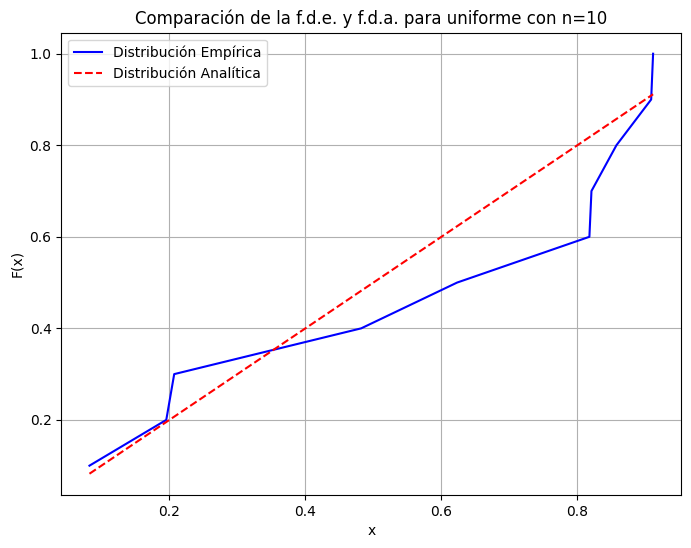

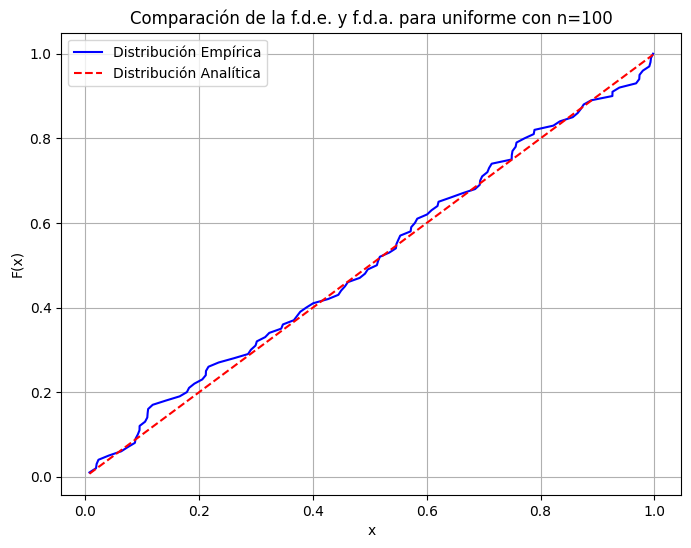

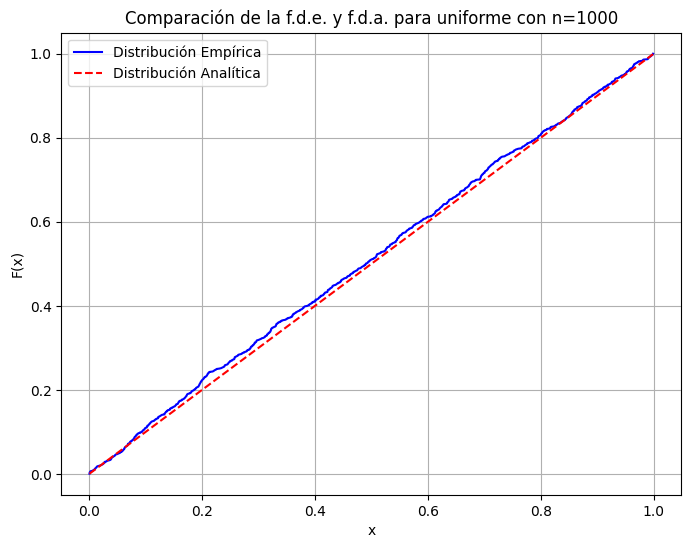

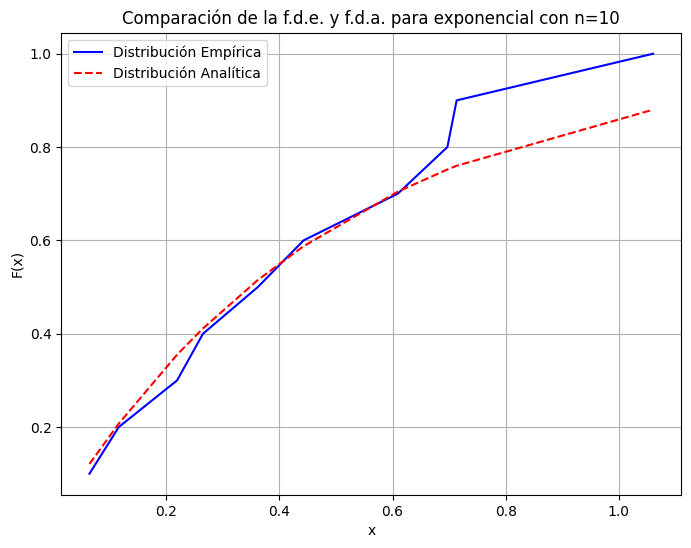

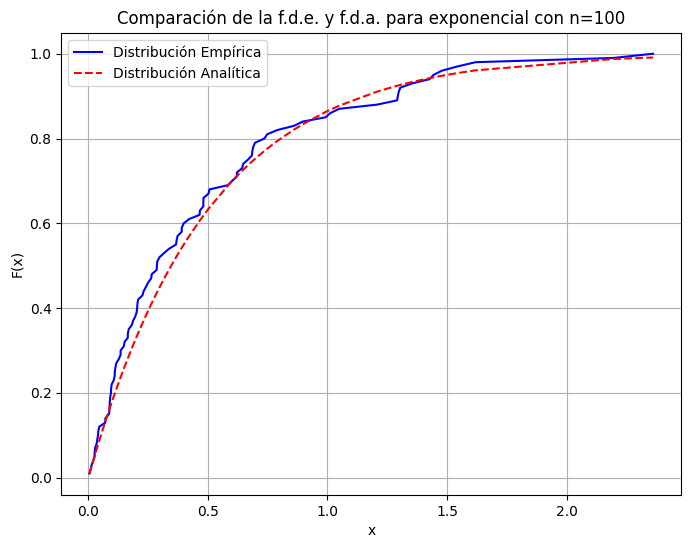

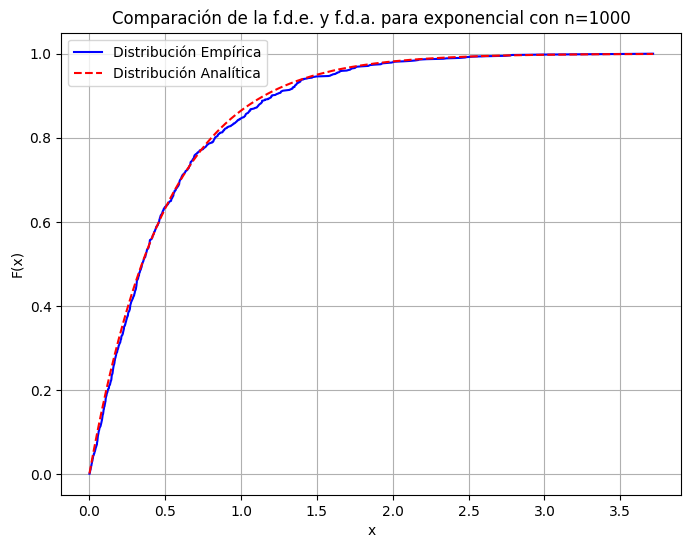

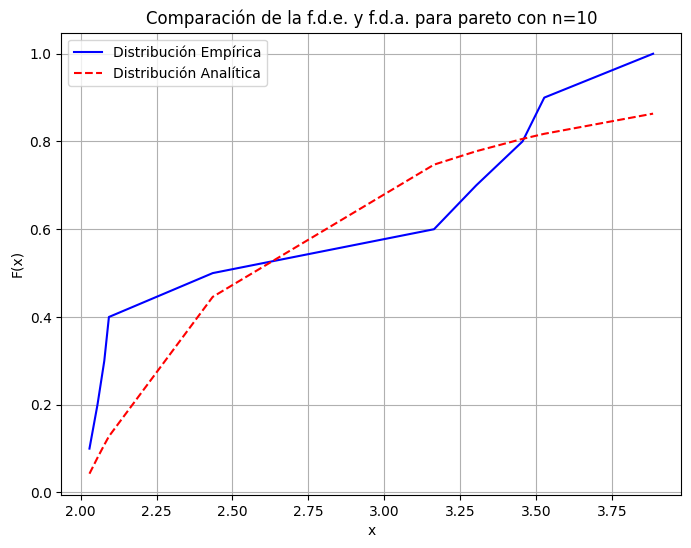

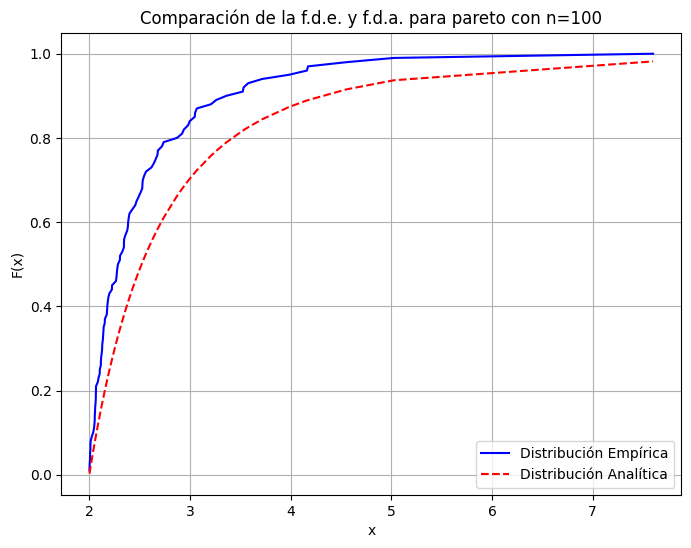

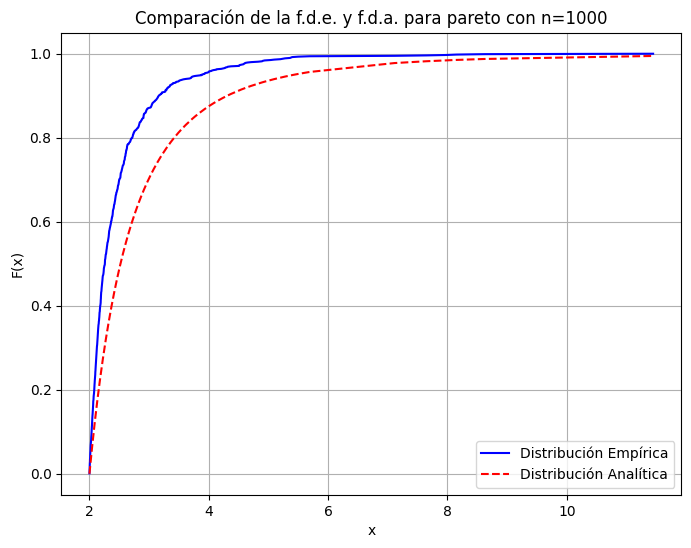

In [6]:
import numpy as np
import matplotlib.pyplot as plt

#Inciso a

def uniforme_cdf(x):
    """Función de distribución acumulada de la distribución Uniforme(0,1)"""
    return np.clip(x, 0, 1)  # Para x fuera de [0, 1], se ajusta a 0 o 1

def exponencial_cdf(x, lambd=2):
    """Función de distribución acumulada para la distribución Exponencial(λ=2)"""
    return 1 - np.exp(-lambd * x) if x >= 0 else 0  # Para x negativo, la CDF es 0

def pareto_cdf(x, alpha=3, c=2):
    """Función de distribución acumulada para la distribución Pareto(α=3, c=2)"""
    return 1 - (c / x) ** alpha if x >= c else 0  # Para x menor que c, la CDF es 0

#Inciso b

def generar_muestra(distribucion, n, **params):
    """Genera una muestra aleatoria para una distribución dada"""
    if distribucion == 'uniforme':
        return np.random.uniform(0, 1, n)
    elif distribucion == 'exponencial':
        return np.random.exponential(1/2, n)  # λ = 2
    elif distribucion == 'pareto':
        return np.random.pareto(3, n) + 2  # α=3, c=2

#Inciso c

def graficar_comparacion(muestra, cdf_analitica, distribucion, n):
    """Genera la gráfica comparando la f.d.e. con la f.d.a."""
    muestras_sorted = np.sort(muestra)
    fde_values = [funcion_distribucion_empirica(x, muestra) for x in muestras_sorted]
    cdf_values = [cdf_analitica(x) for x in muestras_sorted]

    plt.figure(figsize=(8, 6))
    plt.plot(muestras_sorted, fde_values, label='Distribución Empírica', color='blue')
    plt.plot(muestras_sorted, cdf_values, label='Distribución Analítica', color='red', linestyle='--')
    plt.title(f'Comparación de la f.d.e. y f.d.a. para {distribucion} con n={n}')
    plt.xlabel('x')
    plt.ylabel('F(x)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Generamos las muestras de tamaño 10, 100, 1000 para las distribuciones

for distribucion in ['uniforme', 'exponencial', 'pareto']:
    for n in [10, 100, 1000]:
        muestra = generar_muestra(distribucion, n)
        if distribucion == 'uniforme':
            cdf_analitica = uniforme_cdf
        elif distribucion == 'exponencial':
            cdf_analitica = lambda x: exponencial_cdf(x, lambd=2)
        elif distribucion == 'pareto':
            cdf_analitica = lambda x: pareto_cdf(x, alpha=3, c=2)

        # Graficamos cada muestra
        graficar_comparacion(muestra, cdf_analitica, distribucion, n)
